# Импорты и базовые настройки

In [1]:
import os
import re
import sys
import random
import subprocess
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple
import transformers
import torch

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer

os.environ["TOKENIZERS_PARALLELISM"] = "false"


def safe_ensure_package(package_name: str, import_name: Optional[str] = None) -> bool:
    """Пытается импортировать пакет и при необходимости установить его через pip.
    Если установка не удалась, возвращает False, но не роняет ноутбук.
    """
    target = import_name or package_name
    try:
        __import__(target)
        return True
    except Exception:
        print(f"Пробуем установить пакет: {package_name}")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])
            __import__(target)
            return True
        except Exception as e:
            print(f"Не удалось подготовить пакет {package_name}: {e!r}")
            return False


FAISS_READY = safe_ensure_package("faiss-cpu", "faiss")

try:
    import faiss # type: ignore
    FAISS_AVAILABLE = True
except Exception:
    faiss = None
    FAISS_READY = False
    FAISS_AVAILABLE = False

CHUNK_SIZE = 40
OVERLAP = 12


# sentence-transformers опционален: ноутбук умеет работать и без него.
SENTENCE_TRANSFORMERS_READY = safe_ensure_package("sentence-transformers", "sentence_transformers")

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("faiss / faiss-cpu:", faiss.__version__)
print("Transformers:", transformers.__version__)
print("Sklearn:", sklearn.__version__)
print("Torch:", torch.__version__)
if FAISS_READY:
    import faiss
    print("FAISS доступен:", FAISS_READY)
if SENTENCE_TRANSFORMERS_READY: 
    import sentence_transformers
    print("sentence-transformers доступен:", SENTENCE_TRANSFORMERS_READY)
    print("Sentence-transformers:", sentence_transformers.__version__)

NumPy: 2.4.3
Pandas: 3.0.1
faiss / faiss-cpu: 1.13.2
Transformers: 5.4.0
Sklearn: 1.8.0
Torch: 2.10.0+cu128
FAISS доступен: True
sentence-transformers доступен: True
Sentence-transformers: 5.3.0


In [2]:
# Фиксируем seed и определяем устройство.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)


set_seed(42)

try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    DEVICE = "cpu"

print("Устройство для работы:", DEVICE)

Устройство для работы: cuda


# База знаний и первичный анализ

In [3]:
text_labels = ["GNU Automake - Introduction",
               "An introduction to the Autotools",
               "Basic installation with GNU Autotools",
               "How Autotools aid development",
               "General operation of GNU Autotools",
               "Standard Makefile Targets in Autotools",
               "Standard Directory Variables in Autotools",
               "Standard Configuration Variables in Autotools",
               "GNU Autotools Parallel Build Trees",
               "Cross Compilation with GNU Autotools",
              ]
text_labels_added = [
    "GNU Autotools Automatic Dependency Tracking",
    "GNU Autoconf",
]
texts = [open(f"data/doc-{i}.txt","r").read() for i in range(10)]
for i in range(len(texts)):
    print(f"{text_labels[i]}: {texts[i]}\n")
texts_added = [open(f"data/doc-{i}.txt","r").read() for i in range(10,12)]

GNU Automake - Introduction: Automake is a tool for automatically generating Makefile.ins from files called Makefile.am. Each Makefile.am is basically a series of make variable definitions1, with rules being thrown in occasionally. The generated Makefile.ins are compliant with the GNU Makefile standards. The GNU Makefile Standards Document is long, complicated, and subject to change. The goal of Automake is to remove the burden of Makefile maintenance from the back of the individual GNU maintainer (and put it on the back of the Automake maintainers). The typical Automake input file is simply a series of variable definitions. Each such file is processed to create a Makefile.in. Automake does constrain a project in certain ways; for instance, it assumes that the project uses Autoconf (see Introduction in The Autoconf Manual), and enforces certain restrictions on the configure.ac contents. Automake requires perl in order to generate the Makefile.ins. However, the distributions created by 

In [4]:
documents: List[Dict[str, str]] = [ {"doc_id":f"doc_{i}", "title":text_labels[i], "text": texts[i]} for i in range(len(text_labels))]

In [5]:
docs_df = pd.DataFrame(documents)
display(docs_df[["doc_id", "title","text"]])

,doc_id,title,text
0,doc_0,GNU Automake - Introduction,Automake is a tool for automatically generatin...
1,doc_1,An introduction to the Autotools,"It is a truth universally acknowledged, that a..."
2,doc_2,Basic installation with GNU Autotools,"The user first unpacks the package. Here, and ..."
3,doc_3,How Autotools aid development,There are several reasons why you may not want...
4,doc_4,General operation of GNU Autotools,Automake works by reading a Makefile.am and ge...
5,doc_5,Standard Makefile Targets in Autotools,So far we have come across four ways to run ma...
6,doc_6,Standard Directory Variables in Autotools,The GNU Coding Standards also specify a hierar...
7,doc_7,Standard Configuration Variables in Autotools,The GNU Coding Standards also define a set of ...
8,doc_8,GNU Autotools Parallel Build Trees,The GNU Build System distinguishes two trees: ...
9,doc_9,Cross Compilation with GNU Autotools,To cross-compile is to build on one platform a...


#### Документация GNU Autotools - хаотичное побоище, в котором редко можно понять, что происходит. Предметная область - аспекты использования утилит автоматизации сборки GNU Build Tools (или GNU Autotools). Здесь уместно использовать mini-Rag/retrieval, возможно, чтобы упорядочить материал по использованию Autotools или чтобы получить быстрый ответ на вопрос.

# Чанкинг документов

In [6]:
def chunk_text(text: str, chunk_size: int = 30, overlap: int = 10) -> List[str]:
    words = text.split()
    if chunk_size <= 0:
        raise ValueError("chunk_size должен быть положительным.")
    if overlap >= chunk_size:
        raise ValueError("overlap должен быть меньше chunk_size.")

    chunks = []
    step = chunk_size - overlap
    for start in range(0, len(words), step):
        end = start + chunk_size
        chunk_words = words[start:end]
        if not chunk_words:
            continue
        chunks.append(" ".join(chunk_words))
        if end >= len(words):
            break
    return chunks


class EmbeddingBackend:
    def fit_documents(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError


class TfidfBackend(EmbeddingBackend):
    def __init__(self) -> None:
        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2))
        self.backend_name = "TF-IDF (fallback)"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        matrix = self.vectorizer.fit_transform(texts)
        vectors = matrix.astype(np.float32).toarray()
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        matrix = self.vectorizer.transform(texts)
        vectors = matrix.astype(np.float32).toarray()
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms


class SentenceTransformersBackend(EmbeddingBackend):
    def __init__(self, model_name: str, device: str = "cpu") -> None:
        from sentence_transformers import SentenceTransformer  # type: ignore
        self.model_name = model_name
        self.model = SentenceTransformer(model_name, device=device)
        self.backend_name = f"SentenceTransformer: {model_name}"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            normalize_embeddings=True,
            convert_to_numpy=True,
        )
        return vectors.astype(np.float32)

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            normalize_embeddings=True,
            convert_to_numpy=True,
        )
        return vectors.astype(np.float32)


def choose_backend(device: str = "cpu") -> EmbeddingBackend:
    # Опциональная попытка dense backend.
    if SENTENCE_TRANSFORMERS_READY:
        try:
            return SentenceTransformersBackend(
                model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
                device=device,
            )
        except Exception as e:
            print("Dense backend недоступен, переходим к TF-IDF.")
            print("Причина:", repr(e))
    return TfidfBackend()


@dataclass
class RetrieverArtifacts:
    backend_name: str
    chunks_df: pd.DataFrame
    chunk_vectors: np.ndarray
    backend: EmbeddingBackend
    index: object


def build_retriever(
    documents: List[Dict[str, str]],
    chunk_size: int = 28,
    overlap: int = 8,
    device: str = "cpu",
) -> RetrieverArtifacts:
    rows = []
    for doc in documents:
        chunks = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for chunk_id, chunk_text_value in enumerate(chunks, start=1):
            rows.append(
                {
                    "doc_id": doc["doc_id"],
                    "title": doc["title"],
                    "chunk_id": chunk_id,
                    "chunk_text": chunk_text_value,
                    "n_words": len(chunk_text_value.split()),
                }
            )

    chunks_df = pd.DataFrame(rows)
    backend = choose_backend(device=device)
    chunk_vectors = backend.fit_documents(chunks_df["chunk_text"].tolist()).astype(np.float32)

    if FAISS_READY:
        index = faiss.IndexFlatIP(chunk_vectors.shape[1])  # type: ignore
        index.add(chunk_vectors)
    else:
        index = chunk_vectors

    return RetrieverArtifacts(
        backend_name=backend.backend_name,
        chunks_df=chunks_df,
        chunk_vectors=chunk_vectors,
        backend=backend,
        index=index,
    )


def search_chunks(query: str, artifacts: RetrieverArtifacts, top_k: int = 3) -> pd.DataFrame:
    query_vector = artifacts.backend.encode_queries([query]).astype(np.float32)

    if FAISS_READY:
        scores, indices = artifacts.index.search(query_vector, top_k)  # type: ignore
        scores = scores[0]
        indices = indices[0]
    else:
        similarities = (artifacts.chunk_vectors @ query_vector.T).reshape(-1)
        indices = np.argsort(-similarities)[:top_k]
        scores = similarities[indices]

    result = artifacts.chunks_df.iloc[indices].copy().reset_index(drop=True)
    result.insert(0, "rank", np.arange(1, len(result) + 1))
    result["score"] = scores
    return result[["rank", "score", "doc_id", "title", "chunk_id", "chunk_text"]]

### Текст и сами предложения в нем достаточно объемные и часто включают в себя публицистически стилизированные элементы посреди определений, что повлияет на качество ответа, поэтому CHUNK_SIZE и OVERLAP выбраны побольше, но не сильно большими.

In [7]:
artifacts = build_retriever(
    documents,
    chunk_size=CHUNK_SIZE,
    overlap=OVERLAP,
    device=DEVICE,
)

print("Используемый backend:", artifacts.backend_name)
print("Количество чанков:", len(artifacts.chunks_df))
display(artifacts.chunks_df.head())

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используемый backend: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Количество чанков: 91


,doc_id,title,chunk_id,chunk_text,n_words
0,doc_0,GNU Automake - Introduction,1,Automake is a tool for automatically generatin...,40
1,doc_0,GNU Automake - Introduction,2,The generated Makefile.ins are compliant with ...,40
2,doc_0,GNU Automake - Introduction,3,remove the burden of Makefile maintenance from...,40
3,doc_0,GNU Automake - Introduction,4,file is simply a series of variable definition...,40
4,doc_0,GNU Automake - Introduction,5,assumes that the project uses Autoconf (see In...,40


In [8]:
sample_queries = [
    "What are the default Makefile targets for GNU Autotools?",
    "What does Automake do?",
    "Why would I not like to implement GNU Autotools?",
]

for query in sample_queries:
    display(Markdown(f"### Запрос: {query}"))
    display(search_chunks(query, artifacts=artifacts, top_k=3))

### Запрос: What are the default Makefile targets for GNU Autotools?

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.772912,doc_0,GNU Automake - Introduction,2,The generated Makefile.ins are compliant with ...
1,2,0.739728,doc_1,An introduction to the Autotools,14,GNU Build System for your package. Autoconf mo...
2,3,0.721650,doc_0,GNU Automake - Introduction,1,Automake is a tool for automatically generatin...


### Запрос: What does Automake do?

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.667475,doc_0,GNU Automake - Introduction,1,Automake is a tool for automatically generatin...
1,2,0.616378,doc_1,An introduction to the Autotools,13,GNU project. However it is used by a vast numb...
2,3,0.616334,doc_4,General operation of GNU Autotools,1,Automake works by reading a Makefile.am and ge...


### Запрос: Why would I not like to implement GNU Autotools?

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.770509,doc_3,How Autotools aid development,7,there also exist reasons why you may want NOT ...
1,2,0.743484,doc_1,An introduction to the Autotools,13,GNU project. However it is used by a vast numb...
2,3,0.716883,doc_3,How Autotools aid development,5,Autotools take all this burden off your back a...


# Эмбеддинги и индекс FAISS

In [9]:
embedder = choose_backend(device=DEVICE)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [10]:
# Строим векторные представления для всех чанков в ручную.
chunk_texts = artifacts.chunks_df["chunk_text"].tolist()
chunk_embeddings = embedder.fit_documents(chunk_texts)

print("Форма матрицы эмбеддингов:", chunk_embeddings.shape)

# Проверяем длины векторов.
# Если normalize_embeddings=True сработал корректно, все нормы должны быть ≈ 1.0.
# Это означает, что косинусное сходство далее можно считать через скалярное произведение.
vector_norms = np.linalg.norm(chunk_embeddings, axis=1)
print("Минимальная норма:", round(float(vector_norms.min()), 4))
print("Максимальная норма:", round(float(vector_norms.max()), 4))
print("Средняя норма:", round(float(vector_norms.mean()), 4))
print("→ Нормы ≈ 1.0: нормировка подтверждена, dot product = cosine similarity.")

Форма матрицы эмбеддингов: (91, 384)
Минимальная норма: 1.0
Максимальная норма: 1.0
Средняя норма: 1.0
→ Нормы ≈ 1.0: нормировка подтверждена, dot product = cosine similarity.


In [11]:
 # Считаем сходство запроса и всех чанков без FAISS.
query = "Why would I not like to implement GNU Autotools?"
query_vector = embedder.encode_queries([query])

# Для нормализованных векторов это эквивалент косинусного сходства.
manual_scores = (chunk_embeddings @ query_vector.T).ravel()

top_k = 5
top_indices = np.argsort(manual_scores)[::-1][:top_k]

manual_results_df = artifacts.chunks_df.iloc[top_indices].copy()
manual_results_df["score"] = manual_scores[top_indices]
manual_results_df["score"] = manual_results_df["score"].round(4)
manual_results_df.insert(0, "rank", range(1, len(manual_results_df) + 1))

display(Markdown(f"**Запрос:** {query}"))
display(manual_results_df[["rank", "doc_id", "title", "chunk_id", "score", "chunk_text"]])

**Запрос:** Why would I not like to implement GNU Autotools?

,rank,doc_id,title,chunk_id,score,chunk_text
42,1,doc_3,How Autotools aid development,7,0.7705,there also exist reasons why you may want NOT ...
18,2,doc_1,An introduction to the Autotools,13,0.7435,GNU project. However it is used by a vast numb...
40,3,doc_3,How Autotools aid development,5,0.7169,Autotools take all this burden off your back a...
39,4,doc_3,How Autotools aid development,4,0.7064,See Portable Shell Programming in The Autoconf...
19,5,doc_1,An introduction to the Autotools,14,0.6997,GNU Build System for your package. Autoconf mo...


In [12]:
# Единая обёртка над FAISS и fallback-поиском.
class VectorSearchIndex:
    def __init__(self, dim: int) -> None:
        self.dim = dim
        self.backend_name = None
        self._faiss_index = None
        self._nn_index = None

        if FAISS_AVAILABLE:
            self._faiss_index = faiss.IndexFlatIP(dim)  # type: ignore[name-defined]
            self.backend_name = "FAISS IndexFlatIP"
        else:
            self._nn_index = NearestNeighbors(metric="cosine")
            self.backend_name = "sklearn NearestNeighbors fallback"

    def add(self, vectors: np.ndarray) -> None:
        vectors = vectors.astype("float32")

        if self._faiss_index is not None:
            self._faiss_index.add(vectors)
        else:
            self._nn_index.fit(vectors)

    def search(self, query_vectors: np.ndarray, top_k: int = 5) -> Tuple[np.ndarray, np.ndarray]:
        query_vectors = query_vectors.astype("float32")

        if self._faiss_index is not None:
            scores, indices = self._faiss_index.search(query_vectors, top_k)
            return scores, indices

        distances, indices = self._nn_index.kneighbors(query_vectors, n_neighbors=top_k)
        scores = 1.0 - distances
        return scores, indices


search_index = VectorSearchIndex(dim=chunk_embeddings.shape[1])
search_index.add(chunk_embeddings)

print("Индекс построен.")
print("Бэкэнд индекса:", search_index.backend_name)

Индекс построен.
Бэкэнд индекса: FAISS IndexFlatIP


In [13]:
# Проверяем FAISS-поиск на первом запросе.
# Результаты должны совпасть с ручным расчётом из секции 6:
# тот же top-k, те же фрагменты, те же оценки сходства.
faiss_query = "How do i set linker flags?"
faiss_results_df = search_chunks(faiss_query, artifacts, top_k=5)

display(Markdown(f"**Запрос:** {faiss_query}"))
display(faiss_results_df)

**Запрос:** How do i set linker flags?

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.430469,doc_7,Standard Configuration Variables in Autotools,2,flags; CXX - C++ compiler command; CXXFLAGS - ...
1,2,0.396762,doc_7,Standard Configuration Variables in Autotools,5,the linker.Here is how one would call configur...
2,3,0.330572,doc_7,Standard Configuration Variables in Autotools,4,"would like to use another one, you may have he..."
3,4,0.154366,doc_4,General operation of GNU Autotools,14,not copied into the output; all lines beginnin...
4,5,0.152061,doc_4,General operation of GNU Autotools,4,"non-standard rule for the git-dist target, whi..."


In [14]:
def unique_doc_order(result_df: pd.DataFrame) -> List[str]:
    seen = set()
    ordered = []
    for doc_id in result_df["doc_id"].tolist():
        if doc_id not in seen:
            seen.add(doc_id)
            ordered.append(doc_id)
    return ordered
def evaluate_query(
    query: str,
    relevant_doc_ids: List[str],
    artifacts: RetrieverArtifacts,
    top_k: int = 3,
) -> Dict[str, object]:
    result_df = search_chunks(query, artifacts, top_k=top_k)
    predicted_doc_ids = unique_doc_order(result_df)

    hit = int(any(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids))
    recall = sum(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids) / len(relevant_doc_ids)

    first_relevant_rank = None
    for idx, doc_id in enumerate(predicted_doc_ids, start=1):
        if doc_id in relevant_doc_ids:
            first_relevant_rank = idx
            break

    mrr = 0.0 if first_relevant_rank is None else 1.0 / first_relevant_rank

    return {
        "predicted_doc_ids": predicted_doc_ids,
        "hit": hit,
        "recall": recall,
        "first_relevant_rank": first_relevant_rank,
        "mrr": mrr,
        "result_df": result_df,
    }


def evaluate_benchmark(
    benchmark_rows: List[Dict[str, object]],
    artifacts: RetrieverArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    rows = []
    for row in benchmark_rows:
        metrics = evaluate_query(
            query=row["query"],
            relevant_doc_ids=row["relevant_doc_ids"],
            artifacts=artifacts,
            top_k=top_k,
        )
        rows.append(
            {
                "query_id": row["query_id"],
                "query": row["query"],
                "relevant_doc_ids": ", ".join(row["relevant_doc_ids"]),
                "predicted_doc_ids": ", ".join(metrics["predicted_doc_ids"]),
                f"hit@{top_k}": metrics["hit"],
                f"recall@{top_k}": metrics["recall"],
                f"MRR@{top_k}": metrics["mrr"],
                "first_relevant_rank": metrics["first_relevant_rank"],
            }
        )
    return pd.DataFrame(rows)

# Контрольные запросы и оценка retrieval

In [15]:
benchmark_queries: List[Dict[str, object]] = [
    {
        "query_id": "q01",
        "query": "What is the purpose of Automake?",
        "relevant_doc_ids": ["doc_0"],
    },
    {
        "query_id": "q02",
        "query": "What are the Autotools?",
        "relevant_doc_ids": ["doc_0","doc_1","doc_3"],
    },
    {
        "query_id": "q03",
        "query": "What does make installcheck do?",
        "relevant_doc_ids": ["doc_2","doc_5"],
    },
    {
        "query_id": "q04",
        "query": "How many trees tdoes the GNU Build System distinguish?",
        "relevant_doc_ids": ["doc_8"],
    },
    {
        "query_id": "q05",
        "query": "What is a VPATH build?",
        "relevant_doc_ids": ["doc_8"],
    },
    {
        "query_id": "q06",
        "query": "How does Automake handle comments in a Makefile.am file?",
        "relevant_doc_ids": ["doc_4"],
    },
    {
        "query_id": "q07",
        "query": "What are the --build, --host, and --target configure options used for?",
        "relevant_doc_ids": ["doc_9"],
    },
    {
        "query_id": "q08",
        "query": "What is the role of the configure script in the GNU Build System?",
        "relevant_doc_ids": ["doc_1","doc_2","doc_8"],
    },
]
benchmark_df = pd.DataFrame(benchmark_queries)
display(benchmark_df)

,query_id,query,relevant_doc_ids
0,q01,What is the purpose of Automake?,[doc_0]
1,q02,What are the Autotools?,"[doc_0, doc_1, doc_3]"
2,q03,What does make installcheck do?,"[doc_2, doc_5]"
3,q04,How many trees tdoes the GNU Build System dist...,[doc_8]
4,q05,What is a VPATH build?,[doc_8]
5,q06,How does Automake handle comments in a Makefil...,[doc_4]
6,q07,"What are the --build, --host, and --target con...",[doc_9]
7,q08,What is the role of the configure script in th...,"[doc_1, doc_2, doc_8]"


In [16]:
# Прогоняем весь benchmark и считаем метрики для baseline-конфигурации.
baseline_eval_k3 = evaluate_benchmark(benchmark_queries, artifacts=artifacts, top_k=3)
display(baseline_eval_k3)

summary_k3 = pd.DataFrame(
    {
        "metric": ["mean_hit@3", "mean_recall@3", "mean_MRR@3"],
        "value": [
            baseline_eval_k3["hit@3"].mean(),
            baseline_eval_k3["recall@3"].mean(),
            baseline_eval_k3["MRR@3"].mean(),
        ],
    }
)
display(summary_k3)
summary_k3_save_blobb = pd.DataFrame(
    {
        "query": benchmark_df["query"],
        "expected_source": baseline_eval_k3["relevant_doc_ids"],
        "retrieved_sources": baseline_eval_k3["predicted_doc_ids"],
        "hit_at_k": baseline_eval_k3["hit@3"],
    }
)
display(summary_k3_save_blobb)
summary_k3_save_blobb.to_csv("artifacts/retrieval_eval.csv", index=False)

,query_id,query,relevant_doc_ids,predicted_doc_ids,hit@3,recall@3,MRR@3,first_relevant_rank
0,q01,What is the purpose of Automake?,doc_0,"doc_0, doc_4",1,1.000000,1.0,1
1,q02,What are the Autotools?,"doc_0, doc_1, doc_3","doc_3, doc_1",1,0.666667,1.0,1
2,q03,What does make installcheck do?,"doc_2, doc_5",doc_2,1,0.500000,1.0,1
3,q04,How many trees tdoes the GNU Build System dist...,doc_8,doc_8,1,1.000000,1.0,1
4,q05,What is a VPATH build?,doc_8,doc_8,1,1.000000,1.0,1
5,q06,How does Automake handle comments in a Makefil...,doc_4,"doc_4, doc_0",1,1.000000,1.0,1
6,q07,"What are the --build, --host, and --target con...",doc_9,doc_9,1,1.000000,1.0,1
7,q08,What is the role of the configure script in th...,"doc_1, doc_2, doc_8","doc_3, doc_8, doc_1",1,0.666667,0.5,2


,metric,value
0,mean_hit@3,1.000000
1,mean_recall@3,0.854167
2,mean_MRR@3,0.937500


,query,expected_source,retrieved_sources,hit_at_k
0,What is the purpose of Automake?,doc_0,"doc_0, doc_4",1
1,What are the Autotools?,"doc_0, doc_1, doc_3","doc_3, doc_1",1
2,What does make installcheck do?,"doc_2, doc_5",doc_2,1
3,How many trees tdoes the GNU Build System dist...,doc_8,doc_8,1
4,What is a VPATH build?,doc_8,doc_8,1
5,How does Automake handle comments in a Makefil...,doc_4,"doc_4, doc_0",1
6,"What are the --build, --host, and --target con...",doc_9,doc_9,1
7,What is the role of the configure script in th...,"doc_1, doc_2, doc_8","doc_3, doc_8, doc_1",1


# Небольшой эксперимент с параметрами retrieval

,top_k,mean_hit,mean_recall,mean_MRR
0,1,0.875,0.729167,0.8750
1,2,1.000,0.812500,0.9375
2,3,1.000,0.854167,0.9375
3,4,1.000,0.895833,0.9375
4,5,1.000,0.895833,0.9375


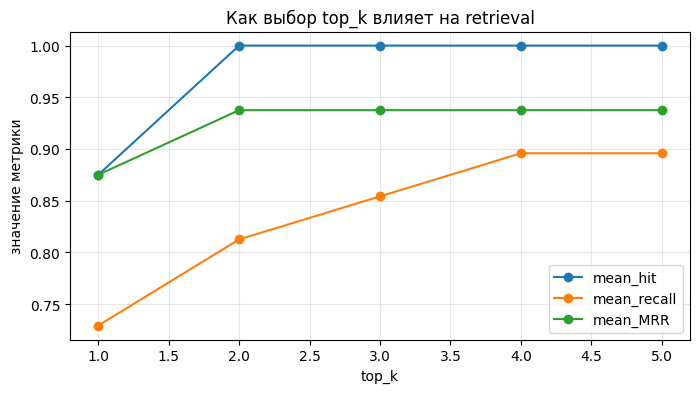

In [17]:
# Фиксируем baseline-конфигурацию и смотрим, как меняются метрики при разных top_k.
topk_rows = []

for top_k in [1, 2, 3, 4, 5]:
    eval_df = evaluate_benchmark(benchmark_queries, artifacts=artifacts, top_k=top_k)
    topk_rows.append(
        {
            "top_k": top_k,
            "mean_hit": eval_df[f"hit@{top_k}"].mean(),
            "mean_recall": eval_df[f"recall@{top_k}"].mean(),
            "mean_MRR": eval_df[f"MRR@{top_k}"].mean(),
        }
    )

topk_df = pd.DataFrame(topk_rows)
display(topk_df)

plt.figure(figsize=(8, 4))
plt.plot(topk_df["top_k"], topk_df["mean_hit"], marker="o", label="mean_hit")
plt.plot(topk_df["top_k"], topk_df["mean_recall"], marker="o", label="mean_recall")
plt.plot(topk_df["top_k"], topk_df["mean_MRR"], marker="o", label="mean_MRR")
plt.xlabel("top_k")
plt.ylabel("значение метрики")
plt.title("Как выбор top_k влияет на retrieval")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Обновление базы знаний и переиндексация

In [18]:
new_documents: List[Dict[str, str]] = [ {"doc_id":f"doc_{i+10}", "title":text_labels_added[i], "text": texts_added[i]} for i in range(len(text_labels_added))]

In [19]:
updated_documents = documents + new_documents

display(pd.DataFrame(new_documents)[["doc_id", "title","text"]])
display(pd.DataFrame(updated_documents)[["doc_id", "title"]])
new_queries = [
    "How to enable dependency tracking using in GNU Autotools?",
    "Which version of GNU Automake requires gcc and GNU make to track dependencies automatically?",
]

display(Markdown("### Как baseline-база отвечает на новые запросы"))
for query in new_queries:
    display(Markdown(f"**Запрос:** {query}"))
    f = search_chunks(query, artifacts=artifacts, top_k=3)
    display(f[["rank", "score", "doc_id", "title", "chunk_text"]])


,doc_id,title,text
0,doc_10,GNU Autotools Automatic Dependency Tracking,Dependency tracking is performed as a side-eff...
1,doc_11,GNU Autoconf,Keeping track of dependencies for a large prog...


,doc_id,title
0,doc_0,GNU Automake - Introduction
1,doc_1,An introduction to the Autotools
2,doc_2,Basic installation with GNU Autotools
3,doc_3,How Autotools aid development
4,doc_4,General operation of GNU Autotools
5,doc_5,Standard Makefile Targets in Autotools
6,doc_6,Standard Directory Variables in Autotools
7,doc_7,Standard Configuration Variables in Autotools
8,doc_8,GNU Autotools Parallel Build Trees
9,doc_9,Cross Compilation with GNU Autotools


### Как baseline-база отвечает на новые запросы

**Запрос:** How to enable dependency tracking using in GNU Autotools?

,rank,score,doc_id,title,chunk_text
0,1,0.568067,doc_3,How Autotools aid development,See Portable Shell Programming in The Autoconf...
1,2,0.533564,doc_1,An introduction to the Autotools,GNU Build System for your package. Autoconf mo...
2,3,0.523748,doc_3,How Autotools aid development,Autotools take all this burden off your back a...


**Запрос:** Which version of GNU Automake requires gcc and GNU make to track dependencies automatically?

,rank,score,doc_id,title,chunk_text
0,1,0.660987,doc_1,An introduction to the Autotools,GNU Build System for your package. Autoconf mo...
1,2,0.638711,doc_0,GNU Automake - Introduction,assumes that the project uses Autoconf (see In...
2,3,0.609046,doc_0,GNU Automake - Introduction,remove the burden of Makefile maintenance from...


In [20]:
# Переиндексируем корпус уже с новыми документами.
updated_artifacts = build_retriever(
    updated_documents,
    chunk_size=CHUNK_SIZE,
    overlap=OVERLAP,
    device=DEVICE,
)

# Расширяем benchmark новыми запросами.
extended_benchmark_queries = benchmark_queries + [
    {
        "query_id": "q09",
        "query": "How to enable dependency tracking using in GNU Autotools?",
        "relevant_doc_ids": ["doc_10","doc_11"],
    },
    {
        "query_id": "q10",
        "query": "Which version of GNU Automake requires gcc and GNU make to track dependencies automatically?",
        "relevant_doc_ids": ["doc_10","doc_11"],
    },
]

before_update_eval = evaluate_benchmark(extended_benchmark_queries, artifacts=artifacts, top_k=3)
after_update_eval = evaluate_benchmark(extended_benchmark_queries, artifacts=updated_artifacts, top_k=3)

comparison_df = before_update_eval.merge(
    after_update_eval,
    on=["query_id", "query", "relevant_doc_ids"],
    suffixes=("_before", "_after"),
)

display(comparison_df)

summary_comparison_df = pd.DataFrame(
    {
        "metric": ["mean_hit@3", "mean_recall@3", "mean_MRR@3"],
        "before_update": [
            before_update_eval["hit@3"].mean(),
            before_update_eval["recall@3"].mean(),
            before_update_eval["MRR@3"].mean(),
        ],
        "after_update": [
            after_update_eval["hit@3"].mean(),
            after_update_eval["recall@3"].mean(),
            after_update_eval["MRR@3"].mean(),
        ],
    }
)
summary_comparison_df["delta"] = summary_comparison_df["after_update"] - summary_comparison_df["before_update"]
display(summary_comparison_df)

display(Markdown("### Как updated-база отвечает на новые запросы"))
for query in new_queries:
    display(Markdown(f"**Запрос:** {query}"))
    display(search_chunks(query, artifacts=updated_artifacts, top_k=3)[["rank", "score", "doc_id", "title", "chunk_text"]])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,query_id,query,relevant_doc_ids,predicted_doc_ids_before,hit@3_before,recall@3_before,MRR@3_before,first_relevant_rank_before,predicted_doc_ids_after,hit@3_after,recall@3_after,MRR@3_after,first_relevant_rank_after
0,q01,What is the purpose of Automake?,doc_0,"doc_0, doc_4",1,1.000000,1.0,1.0,"doc_0, doc_4",1,1.000000,1.0,1
1,q02,What are the Autotools?,"doc_0, doc_1, doc_3","doc_3, doc_1",1,0.666667,1.0,1.0,"doc_3, doc_1",1,0.666667,1.0,1
2,q03,What does make installcheck do?,"doc_2, doc_5",doc_2,1,0.500000,1.0,1.0,doc_2,1,0.500000,1.0,1
3,q04,How many trees tdoes the GNU Build System dist...,doc_8,doc_8,1,1.000000,1.0,1.0,doc_8,1,1.000000,1.0,1
4,q05,What is a VPATH build?,doc_8,doc_8,1,1.000000,1.0,1.0,doc_8,1,1.000000,1.0,1
5,q06,How does Automake handle comments in a Makefil...,doc_4,"doc_4, doc_0",1,1.000000,1.0,1.0,"doc_4, doc_0",1,1.000000,1.0,1
6,q07,"What are the --build, --host, and --target con...",doc_9,doc_9,1,1.000000,1.0,1.0,doc_9,1,1.000000,1.0,1
7,q08,What is the role of the configure script in th...,"doc_1, doc_2, doc_8","doc_3, doc_8, doc_1",1,0.666667,0.5,2.0,"doc_3, doc_8, doc_1",1,0.666667,0.5,2
8,q09,How to enable dependency tracking using in GNU...,"doc_10, doc_11","doc_3, doc_1",0,0.000000,0.0,NaN,"doc_11, doc_10",1,1.000000,1.0,1
9,q10,Which version of GNU Automake requires gcc and...,"doc_10, doc_11","doc_1, doc_0",0,0.000000,0.0,NaN,"doc_11, doc_10",1,1.000000,1.0,1


,metric,before_update,after_update,delta
0,mean_hit@3,0.800000,1.000000,0.2
1,mean_recall@3,0.683333,0.883333,0.2
2,mean_MRR@3,0.750000,0.950000,0.2


### Как updated-база отвечает на новые запросы

**Запрос:** How to enable dependency tracking using in GNU Autotools?

,rank,score,doc_id,title,chunk_text
0,1,0.777683,doc_11,GNU Autoconf,"#include to an existing header, the change is ..."
1,2,0.771376,doc_11,GNU Autoconf,in the distributed ‘Makefile’s. The new implem...
2,3,0.759763,doc_10,GNU Autotools Automatic Dependency Tracking,Automake generates code for automatic dependen...


**Запрос:** Which version of GNU Automake requires gcc and GNU make to track dependencies automatically?

,rank,score,doc_id,title,chunk_text
0,1,0.827895,doc_11,GNU Autoconf,implementation of automatic dependency trackin...
1,2,0.776356,doc_10,GNU Autotools Automatic Dependency Tracking,Automake generates code for automatic dependen...
2,3,0.759063,doc_11,GNU Autoconf,portable. If you can’t use gcc or GNU make for...


In [21]:
print(comparison_df.columns)
update_df_save_blobb = pd.DataFrame(
    {
        "query":comparison_df["query"],
        "before_retrieved_sources":comparison_df["predicted_doc_ids_before"],
        "after_retrieved_sources":comparison_df["predicted_doc_ids_after"],
        "changed":comparison_df["predicted_doc_ids_before"] != comparison_df["predicted_doc_ids_after"],
    }
)
update_df_save_blobb.to_csv("artifacts/retrieval_before_after_update.csv", index=False)
display(update_df_save_blobb)

Index(['query_id', 'query', 'relevant_doc_ids', 'predicted_doc_ids_before',
       'hit@3_before', 'recall@3_before', 'MRR@3_before',
       'first_relevant_rank_before', 'predicted_doc_ids_after', 'hit@3_after',
       'recall@3_after', 'MRR@3_after', 'first_relevant_rank_after'],
      dtype='str')


,query,before_retrieved_sources,after_retrieved_sources,changed
0,What is the purpose of Automake?,"doc_0, doc_4","doc_0, doc_4",False
1,What are the Autotools?,"doc_3, doc_1","doc_3, doc_1",False
2,What does make installcheck do?,doc_2,doc_2,False
3,How many trees tdoes the GNU Build System dist...,doc_8,doc_8,False
4,What is a VPATH build?,doc_8,doc_8,False
5,How does Automake handle comments in a Makefil...,"doc_4, doc_0","doc_4, doc_0",False
6,"What are the --build, --host, and --target con...",doc_9,doc_9,False
7,What is the role of the configure script in th...,"doc_3, doc_8, doc_1","doc_3, doc_8, doc_1",False
8,How to enable dependency tracking using in GNU...,"doc_3, doc_1","doc_11, doc_10",True
9,Which version of GNU Automake requires gcc and...,"doc_1, doc_0","doc_11, doc_10",True


# Mini-RAG

In [22]:
def split_into_sentences(text: str) -> List[str]:
    parts = re.split(r"(?<=[.!?])\s+", text.strip())
    return [p.strip() for p in parts if p.strip()]


def pick_best_sentences(query: str, text: str, top_n: int = 2) -> List[str]:
    sentences = split_into_sentences(text)
    if not sentences:
        return []

    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform([query] + sentences).toarray().astype(np.float32)

    query_vec = matrix[0]
    sentence_vecs = matrix[1:]

    query_norm = np.linalg.norm(query_vec) + 1e-12
    sent_norms = np.linalg.norm(sentence_vecs, axis=1) + 1e-12
    scores = (sentence_vecs @ query_vec) / (sent_norms * query_norm)

    best_idx = np.argsort(-scores)[:top_n]
    return [sentences[i] for i in best_idx if scores[i] > 0]


def answer_without_retrieval(query: str, documents: List[Dict[str, str]]) -> Dict[str, object]:
    doc_texts = [doc["title"] + ". " + doc["text"] for doc in documents]
    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform(doc_texts + [query]).toarray().astype(np.float32)

    doc_vecs = matrix[:-1]
    query_vec = matrix[-1]

    doc_norms = np.linalg.norm(doc_vecs, axis=1) + 1e-12
    query_norm = np.linalg.norm(query_vec) + 1e-12
    scores = (doc_vecs @ query_vec) / (doc_norms * query_norm)

    best_idx = int(np.argmax(scores))
    best_doc = documents[best_idx]
    best_sentences = pick_best_sentences(query, best_doc["text"], top_n=2)

    if best_sentences:
        answer = " ".join(best_sentences)
    else:
        answer = (
            "Не удалось уверенно извлечь ответ без retrieval по чанкам. "
            "Система выбрала наиболее похожий документ целиком."
        )

    return {
        "answer": answer,
        "selected_doc_id": best_doc["doc_id"],
        "selected_title": best_doc["title"],
        "score": float(scores[best_idx]),
    }

In [23]:
baseline_example = answer_without_retrieval(
    "What are the --build and --host configure options used for?",
    documents,
)

display(pd.DataFrame([baseline_example]))

,answer,selected_doc_id,selected_title,score
0,The following configure options are used to sp...,doc_9,Cross Compilation with GNU Autotools,0.139949


In [24]:

def build_context_from_retrieval(query: str, artifacts: RetrieverArtifacts, top_k: int = 3) -> Tuple[str, pd.DataFrame]:
    retrieved = search_chunks(query, artifacts=artifacts, top_k=top_k)
    context_blocks = []

    for _, row in retrieved.iterrows():
        block = (
            f"[Источник: {row['doc_id']} | {row['title']} | score={row['score']:.4f}]\n"
            f"{row['chunk_text']}"
        )
        context_blocks.append(block)

    context = "\n\n".join(context_blocks)
    return context, retrieved

In [25]:
query = "What are the --build and --host configure options used for?"
context, retrieved_df = build_context_from_retrieval(query, artifacts=artifacts, top_k=3)

display(Markdown(f"### Запрос: {query}"))
display(retrieved_df)
print(context)

### Запрос: What are the --build and --host configure options used for?

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.691130,doc_9,Cross Compilation with GNU Autotools,2,platform on which the compilation is performed...
1,2,0.677558,doc_9,Cross Compilation with GNU Autotools,3,each of them: --build=build - The system on wh...
2,3,0.507878,doc_9,Cross Compilation with GNU Autotools,6,being built is itself a cross-compiler: we nee...


[Источник: doc_9 | Cross Compilation with GNU Autotools | score=0.6911]
platform on which the compilation is performed, and the host platform on which the resulting executable is expected to run. The following configure options are used to specify each of them: --build=build - The system on which the package is

[Источник: doc_9 | Cross Compilation with GNU Autotools | score=0.6776]
each of them: --build=build - The system on which the package is built. --host=host - The system where built programs and libraries will run. When the --host is used, configure will search for the cross-compiling suite for this platform. Cross-compilation

[Источник: doc_9 | Cross Compilation with GNU Autotools | score=0.5079]
being built is itself a cross-compiler: we need a third option to specify its target architecture. --target=target - When building compiler tools: the system for which the tools will create output. For instance when installing GCC, the GNU Compiler Collection,


In [26]:
def generate_answer_from_context(query: str, context: str, max_sentences: int = 2) -> str:
    # Убираем технические строки источников из ранжирования, но не из общего контекста.
    raw_lines = [line.strip() for line in context.splitlines() if line.strip()]
    content_lines = [line for line in raw_lines if not line.startswith("[Источник:")]

    sentence_pool = []
    for line in content_lines:
        sentence_pool.extend(split_into_sentences(line))

    sentence_pool = [s for s in sentence_pool if len(s.split()) >= 4]

    if not sentence_pool:
        return "Недостаточно контекста для построения ответа."

    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform([query] + sentence_pool).toarray().astype(np.float32)

    query_vec = matrix[0]
    sentence_vecs = matrix[1:]

    query_norm = np.linalg.norm(query_vec) + 1e-12
    sent_norms = np.linalg.norm(sentence_vecs, axis=1) + 1e-12
    scores = (sentence_vecs @ query_vec) / (sent_norms * query_norm)

    ranked_idx = np.argsort(-scores)
    selected_sentences = []
    used_normalized = set()

    for idx in ranked_idx:
        sentence = sentence_pool[idx]
        normalized = sentence.lower().strip()
        if scores[idx] <= 0:
            continue
        if normalized in used_normalized:
            continue
        used_normalized.add(normalized)
        selected_sentences.append(sentence)
        if len(selected_sentences) >= max_sentences:
            break

    if not selected_sentences:
        return "В найденном контексте нет достаточно релевантного фрагмента для уверенного ответа."

    return " ".join(selected_sentences)

In [27]:
answer_example = generate_answer_from_context(query, context)
print(answer_example)

The following configure options are used to specify each of them: --build=build - The system on which the package is When the --host is used, configure will search for the cross-compiling suite for this platform.


In [28]:
def mini_rag_answer(
    query: str,
    artifacts: RetrieverArtifacts,
    top_k: int = 3,
    max_answer_sentences: int = 2,
) -> Dict[str, object]:
    context, retrieved = build_context_from_retrieval(query, artifacts=artifacts, top_k=top_k)
    answer = generate_answer_from_context(query, context=context, max_sentences=max_answer_sentences)

    return {
        "query": query,
        "answer": answer,
        "context": context,
        "sources": retrieved,
    }

In [29]:
rag_result = mini_rag_answer(
    "What is the three-way cross-compilation called ",
    artifacts=artifacts,
    top_k=3,
)

display(Markdown(f"### Вопрос: {rag_result['query']}"))
display(Markdown(f"**Ответ:** {rag_result['answer']}"))
display(Markdown("**Источники:**"))
display(rag_result["sources"])

### Вопрос: What is the three-way cross-compilation called 

**Ответ:** Mixing --build and --target, we can cross-compile a cross-compiler; such a three-way cross-compilation is known as a Canadian cross. When speaking of cross-compilation, it is important to distinguish between the build platform on which the compilation is performed, and the host platform on

**Источники:**

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.669036,doc_9,Cross Compilation with GNU Autotools,8,"target. Mixing --build and --target, we can cr..."
1,2,0.656125,doc_9,Cross Compilation with GNU Autotools,1,To cross-compile is to build on one platform a...
2,3,0.515024,doc_9,Cross Compilation with GNU Autotools,6,being built is itself a cross-compiler: we nee...


In [30]:
comparison_queries = [
    "What is the purpose of Automake?",
    "What does make installcheck do?",
    "What are the --build, --host, and --target configure options used for?",
    "What is the role of the configure script in the GNU Build System?",
    "What is a VPATH build?",
]

comparison_rows = []

for query in comparison_queries:
    baseline = answer_without_retrieval(query, documents)
    rag = mini_rag_answer(query, artifacts=artifacts, top_k=3)

    comparison_rows.append(
        {
            "query": query,
            "baseline_doc_id": baseline["selected_doc_id"],
            "baseline_score": baseline["score"],
            "baseline_answer": baseline["answer"],
            "rag_answer": rag["answer"],
        }
    )

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

,query,baseline_doc_id,baseline_score,baseline_answer,rag_answer
0,What is the purpose of Automake?,doc_0,0.150933,The goal of Automake is to remove the burden o...,file is simply a series of variable definition...
1,What does make installcheck do?,doc_5,0.161595,make installcheck - Check the installed progra...,Our toy package is no better: make installchec...
2,"What are the --build, --host, and --target con...",doc_9,0.177807,The --host and --build options are usually all...,The following configure options are used to sp...
3,What is the role of the configure script in th...,doc_1,0.301885,We call this build system the GNU Build System...,is rooted in the directory containing the conf...
4,What is a VPATH build?,doc_8,0.122266,Here is how we could run configure to create e...,Here is how we could run configure to create e...


In [31]:
for _, row in comparison_df.iterrows():
    display(Markdown(f"## Вопрос: {row['query']}"))
    display(Markdown(f"**Baseline без retrieval:** {row['baseline_answer']}"))
    display(Markdown(f"**Mini-RAG:** {row['rag_answer']}"))

## Вопрос: What is the purpose of Automake?

**Baseline без retrieval:** The goal of Automake is to remove the burden of Makefile maintenance from the back of the individual GNU maintainer (and put it on the back of the Automake maintainers). The typical Automake input file is simply a series of variable definitions.

**Mini-RAG:** file is simply a series of variable definitions. The generated Makefile.ins are compliant with the GNU Makefile standards.

## Вопрос: What does make installcheck do?

**Baseline без retrieval:** make installcheck - Check the installed programs or libraries, if supported. So far we have come across four ways to run make in the GNU Build System: make, make check, make install, and make installcheck.

...

**Baseline без retrieval:** We call this build system the GNU Build System, since it was grown out of the GNU project. The GNU Coding Standards (see The Release Process in The GNU Coding Standards) explains how each package of the GNU project should have a configure script, and the minimal interface it should have.

**Mini-RAG:** is rooted in the directory containing the configure script. The build tree is rooted in the current directory at the time configure was

## Вопрос: What is a VPATH build?

**Baseline без retrieval:** Here is how we could run configure to create everything in a build tree (that is, subdirectory) called build/. The expression parallel build is misleading: the word parallel is a reference to the way the build tree shadows the source tree, it is not about some concurrency in the way build commands are run.

**Mini-RAG:** Here is how we could run configure to create everything in a build tree (that is, subdirectory) called build/. VPATH is the name of the

In [32]:
query = "What is a VPATH build?"
rag_result = mini_rag_answer(query, artifacts=artifacts, top_k=3)

display(Markdown(f"### Вопрос: {query}"))
display(Markdown(f"**Ответ:** {rag_result['answer']}"))
display(rag_result["sources"][["rank", "score", "doc_id", "title", "chunk_text"]])

### Вопрос: What is a VPATH build?

**Ответ:** Here is how we could run configure to create everything in a build tree (that is, subdirectory) called build/. VPATH is the name of the

,rank,score,doc_id,title,chunk_text
0,1,0.774681,doc_8,GNU Autotools Parallel Build Trees,name VPATH builds in the following. VPATH is t...
1,2,0.689130,doc_8,GNU Autotools Parallel Build Trees,"tree shadows the source tree, it is not about ..."
2,3,0.514118,doc_8,GNU Autotools Parallel Build Trees,source directories uncluttered. Here is how we...


In [33]:
qa_benchmark = [
    {
        "query_id": "q01",
        "query": "What is the purpose of Automake?",
        "relevant_doc_ids": ["doc_0"],
        "expected_keywords": ["Automake", "tool", "generating"],
    },
    {
        "query_id": "q02",
        "query": "What are the Autotools?",
        "relevant_doc_ids": ["doc_0","doc_1","doc_3"],
        "expected_keywords": ["Automake", "configure", "System"],
    },
    {
        "query_id": "q03",
        "query": "What does make installcheck do?",
        "relevant_doc_ids": ["doc_2","doc_5"],
        "expected_keywords": ["tests", "nothing"],
    },
    {
        "query_id": "q04",
        "query": "What is the role of the configure script in the GNU Build System?",
        "relevant_doc_ids": ["doc_1","doc_2","doc_8"],
        "expected_keywords": ["configure", "probes", "features", "Makefile"],
    },
    {
        "query_id": "q05",
        "query": "What are the --build, --host, and --target configure options used for?",
        "relevant_doc_ids": ["doc_9"],
        "expected_keywords": ["host", "target", "build"],
    },
]

def keyword_recall(answer: str, expected_keywords: List[str]) -> float:
    answer_lower = answer.lower()
    hits = sum(1 for kw in expected_keywords if kw.lower() in answer_lower)
    return hits / len(expected_keywords) if expected_keywords else np.nan


def evaluate_mini_rag(
    benchmark_rows: List[Dict[str, object]],
    artifacts: RetrieverArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    rows = []

    for item in benchmark_rows:
        query = item["query"]
        relevant_doc_ids = item["relevant_doc_ids"]
        expected_keywords = item["expected_keywords"]

        retrieved = search_chunks(query, artifacts=artifacts, top_k=top_k)
        predicted_doc_ids = retrieved["doc_id"].tolist()
        retrieval_hit = int(any(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids))

        baseline = answer_without_retrieval(query, documents)
        rag = mini_rag_answer(query, artifacts=artifacts, top_k=top_k)

        rows.append(
            {
                "query_id": item["query_id"],
                "query": query,
                "relevant_doc_ids": ", ".join(relevant_doc_ids),
                "predicted_doc_ids": ", ".join(predicted_doc_ids),
                f"retrieval_hit@{top_k}": retrieval_hit,
                "baseline_keyword_recall": keyword_recall(baseline["answer"], expected_keywords),
                "rag_keyword_recall": keyword_recall(rag["answer"], expected_keywords),
                "baseline_answer": baseline["answer"],
                "rag_answer": rag["answer"],
            }
        )

    return pd.DataFrame(rows)

In [34]:
evaluation_df = evaluate_mini_rag(qa_benchmark, artifacts=artifacts, top_k=3)
display(evaluation_df)

,query_id,query,relevant_doc_ids,predicted_doc_ids,retrieval_hit@3,baseline_keyword_recall,rag_keyword_recall,baseline_answer,rag_answer
0,q01,What is the purpose of Automake?,doc_0,"doc_0, doc_4, doc_0",1,0.333333,0.000000,The goal of Automake is to remove the burden o...,file is simply a series of variable definition...
1,q02,What are the Autotools?,"doc_0, doc_1, doc_3","doc_3, doc_1, doc_3",1,0.333333,0.333333,The Autotools are tools that will create a GNU...,The Autotools are tools that will create a GNU...
2,q03,What does make installcheck do?,"doc_2, doc_5","doc_2, doc_2, doc_2",1,0.000000,1.000000,make installcheck - Check the installed progra...,Our toy package is no better: make installchec...
3,q04,What is the role of the configure script in th...,"doc_1, doc_2, doc_8","doc_3, doc_8, doc_1",1,0.250000,0.250000,We call this build system the GNU Build System...,is rooted in the directory containing the conf...
4,q05,"What are the --build, --host, and --target con...",doc_9,"doc_9, doc_9, doc_9",1,0.666667,0.666667,The --host and --build options are usually all...,The following configure options are used to sp...


In [35]:
summary_df = pd.DataFrame(
    {
        "metric": ["mean_retrieval_hit@3", "mean_baseline_keyword_recall", "mean_rag_keyword_recall"],
        "value": [
            evaluation_df["retrieval_hit@3"].mean(),
            evaluation_df["baseline_keyword_recall"].mean(),
            evaluation_df["rag_keyword_recall"].mean(),
        ],
    }
)
display(summary_df)
rag_df_save_blobb = pd.DataFrame(
    {
        "question":evaluation_df["query"],
        "answer":evaluation_df["rag_answer"],
        "retrieved_sources":evaluation_df["predicted_doc_ids"],
    }
)
rag_df_save_blobb.to_csv("artifacts/rag_examples.csv", index=False)
display(rag_df_save_blobb)

,metric,value
0,mean_retrieval_hit@3,1.000000
1,mean_baseline_keyword_recall,0.316667
2,mean_rag_keyword_recall,0.450000


,question,answer,retrieved_sources
0,What is the purpose of Automake?,file is simply a series of variable definition...,"doc_0, doc_4, doc_0"
1,What are the Autotools?,The Autotools are tools that will create a GNU...,"doc_3, doc_1, doc_3"
2,What does make installcheck do?,Our toy package is no better: make installchec...,"doc_2, doc_2, doc_2"
3,What is the role of the configure script in th...,is rooted in the directory containing the conf...,"doc_3, doc_8, doc_1"
4,"What are the --build, --host, and --target con...",The following configure options are used to sp...,"doc_9, doc_9, doc_9"


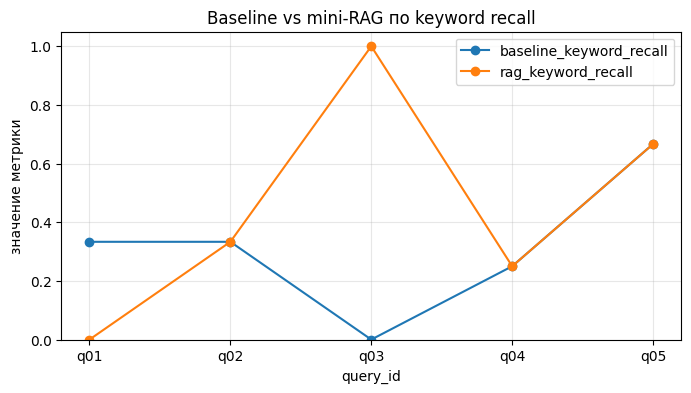

In [36]:
plt.figure(figsize=(8, 4))
plt.plot(
    evaluation_df["query_id"],
    evaluation_df["baseline_keyword_recall"],
    marker="o",
    label="baseline_keyword_recall",
)
plt.plot(
    evaluation_df["query_id"],
    evaluation_df["rag_keyword_recall"],
    marker="o",
    label="rag_keyword_recall",
)
plt.ylim(0, 1.05)
plt.xlabel("query_id")
plt.ylabel("значение метрики")
plt.title("Baseline vs mini-RAG по keyword recall")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Анализ плохих кейсов

In [37]:
weak_cases = evaluation_df[
    evaluation_df["rag_keyword_recall"] < evaluation_df["rag_keyword_recall"].max()
].reset_index(drop=True)

display(weak_cases if len(weak_cases) > 0 else evaluation_df.head(0))

if len(weak_cases) == 0:
    print("На этом маленьком benchmark все ответы mini-RAG достигли одинакового keyword recall.")
else:
    print("Эти вопросы стоит разобрать вручную: проблема может быть в retrieval, чанкинге или самом генераторе ответа.")

,query_id,query,relevant_doc_ids,predicted_doc_ids,retrieval_hit@3,baseline_keyword_recall,rag_keyword_recall,baseline_answer,rag_answer
0,q01,What is the purpose of Automake?,doc_0,"doc_0, doc_4, doc_0",1,0.333333,0.000000,The goal of Automake is to remove the burden o...,file is simply a series of variable definition...
1,q02,What are the Autotools?,"doc_0, doc_1, doc_3","doc_3, doc_1, doc_3",1,0.333333,0.333333,The Autotools are tools that will create a GNU...,The Autotools are tools that will create a GNU...
2,q04,What is the role of the configure script in th...,"doc_1, doc_2, doc_8","doc_3, doc_8, doc_1",1,0.250000,0.250000,We call this build system the GNU Build System...,is rooted in the directory containing the conf...
3,q05,"What are the --build, --host, and --target con...",doc_9,"doc_9, doc_9, doc_9",1,0.666667,0.666667,The --host and --build options are usually all...,The following configure options are used to sp...


Эти вопросы стоит разобрать вручную: проблема может быть в retrieval, чанкинге или самом генераторе ответа.


In [38]:
for _, row in weak_cases.iterrows():
    display(Markdown(f"### Слабый кейс: {row['query']}"))
    rag = mini_rag_answer(row["query"], artifacts=artifacts, top_k=3)
    display(Markdown(f"**Ответ mini-RAG:** {rag['answer']}"))
    display(rag["sources"][["rank", "score", "doc_id", "title", "chunk_text"]])

### Слабый кейс: What is the purpose of Automake?

**Ответ mini-RAG:** file is simply a series of variable definitions. The generated Makefile.ins are compliant with the GNU Makefile standards.

,rank,score,doc_id,title,chunk_text
0,1,0.712371,doc_0,GNU Automake - Introduction,Automake is a tool for automatically generatin...
1,2,0.671306,doc_4,General operation of GNU Autotools,Automake works by reading a Makefile.am and ge...
2,3,0.642031,doc_0,GNU Automake - Introduction,file is simply a series of variable definition...


### Слабый кейс: What are the Autotools?

**Ответ mini-RAG:** The Autotools are tools that will create a GNU Build System for your package. there also exist reasons why you may want NOT to use the Autotools...

...

**Ответ mini-RAG:** is rooted in the directory containing the configure script. The build tree is rooted in the current directory at the time configure was

,rank,score,doc_id,title,chunk_text
0,1,0.659481,doc_3,How Autotools aid development,There are several reasons why you may not want...
1,2,0.633498,doc_8,GNU Autotools Parallel Build Trees,is rooted in the directory containing the conf...
2,3,0.630903,doc_1,An introduction to the Autotools,the GNU project should have a configure script...


### Слабый кейс: What are the --build, --host, and --target configure options used for?

**Ответ mini-RAG:** The following configure options are used to specify each of them: --build=build - The system on which the package is When the --host is used, configure will search for the cross-compiling suite for this platform.

,rank,score,doc_id,title,chunk_text
0,1,0.690087,doc_9,Cross Compilation with GNU Autotools,platform on which the compilation is performed...
1,2,0.658462,doc_9,Cross Compilation with GNU Autotools,each of them: --build=build - The system on wh...
2,3,0.601363,doc_9,Cross Compilation with GNU Autotools,being built is itself a cross-compiler: we nee...


### Из 4 кейсов - второй и четвертый нормальные, но в четвертом не совсем полный ответ на вопрос. Опять же, на это повлияло качество базы знаний, так как текст там плохо структурирован для такого чанкинга. Также стоит отметить, что второй кейс достаточно общий и mini-RAG и retriever тяжело справиться с таким вопросом.